# 07 — Rüzgar ön-tahmin arızası: teşhis + düzeltme testi

**İlgili:** `WIND_PREFORECAST_INCIDENT_2026-08.md`, `LAGO_BENCHMARK_PLAN.md` Faz C.5

**Kullanıcı raporu (29 Ağu 2026):** canlı fiyat tahmini "3 gündür patlıyor" — 28-29-30 Ağustos
sistematik olarak fazla tahmin.

Bu defter üç şeyi gösterir:
1. **Kök sebep** — canlı `predicted_wind_lag0` 25 Ağustos'tan beri düz ~2300 MW; ileri rüzgar
   hızı (OpenMeteo forecast API) üretimde **hiç çağrılmıyor**, model `kgup_wind_lag_*`'a düşüyor.
2. **Lag azaltmak işe yaramıyor** — raporun ilk hipotezinin tersine, lag sayısını düşürmek
   BIAS'ı kötüleştiriyor (`wind_lag_test_results.csv`).
3. **Düzgün meteo ile düzeltme** — `train_and_predict_pre_forecasters`'ı DEĞİŞTİRMEDEN, ön-tahmincinin
   ileri rüzgar hızı girdisini **OpenMeteo forecast API**'sinden (29-30 Ağu = gerçek D-1 tahmini,
   25-28 Ağu = arşiv reanaliz) vererek walk-forward → Ağu 28-29 rüzgar ön-tahmin WAPE %72 → %15.
   Fiyat modeli de canlının T->T+1 proxy'siyle koşuldu (`--proxy-from`), hedef-gün sızıntısı yok:
   Ağu 28-30 fiyat fazla-tahmini +$11.9 → +$6.8.

**Not — "rüzgar forecasti mi kullandın, gerçekleşen mi?"** İki ayrı kanal var:
(a) *ön-tahmincinin* rüzgar HIZI girdisi: 29-30 Ağu için forecast API'den gerçek tahmin, 25-28 Ağu
için arşiv (hafif iyimser). (b) *fiyat modelinin* hedef-gün yük/KGÜP'ü: artık hepsi T->T+1 proxy
(dünün gerçekleşeni), canlıyla birebir. İlk koşumda (b) gerçekleşendi (~$1 daha düşük bias); proxy'li
sürüm burada.


In [1]:
import sys, os
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sqlalchemy import text
ROOT = Path.cwd().parents[2]; sys.path.insert(0, str(ROOT))
from db.connection import get_db_engine
H = Path.cwd()
IST = "Europe/Istanbul"
eng = get_db_engine()

def toist(ix):
    ix = pd.DatetimeIndex(ix)
    return ix.tz_localize(IST) if ix.tz is None else ix.tz_convert(IST)

def q(sql, col):
    d = pd.read_sql(text(sql), eng)
    d.iloc[:, 0] = pd.to_datetime(d.iloc[:, 0], utc=True)
    s = d.set_index(d.columns[0])[col]
    return s.set_axis(toist(s.index)).sort_index()

def wf_daily(tag):
    d = pd.read_csv(H / f"wf_lgbm_{tag}.csv", index_col=0, parse_dates=True)
    d.index = toist(d.index)
    out = {}
    for day, row in d.iterrows():
        for h in range(24):
            out[day.replace(hour=h)] = row[f"h{h:02d}"]
    return pd.Series(out).sort_index()


## 1. Kök sebep — canlı rüzgar ön-tahmini 25 Ağustos'ta düz eğriye çöküyor

                           gerçek KGÜP rüzgar  canlı predicted_wind_lag0  düzeltilmiş (bu defter)
2026-08-08 00:00:00+03:00              6112.0                     5395.0                      NaN
2026-08-09 00:00:00+03:00              9134.0                     7325.0                      NaN
2026-08-10 00:00:00+03:00              9367.0                     8658.0                   8658.0
2026-08-11 00:00:00+03:00              7350.0                     7435.0                   7435.0
2026-08-12 00:00:00+03:00              8062.0                     7097.0                   7097.0
2026-08-13 00:00:00+03:00             10783.0                     8704.0                   8715.0
2026-08-14 00:00:00+03:00             11021.0                    10323.0                  10114.0
2026-08-15 00:00:00+03:00             10025.0                     9742.0                   9601.0
2026-08-16 00:00:00+03:00              7751.0                     7866.0                   7827.0
2026-08-17 00:00:00+

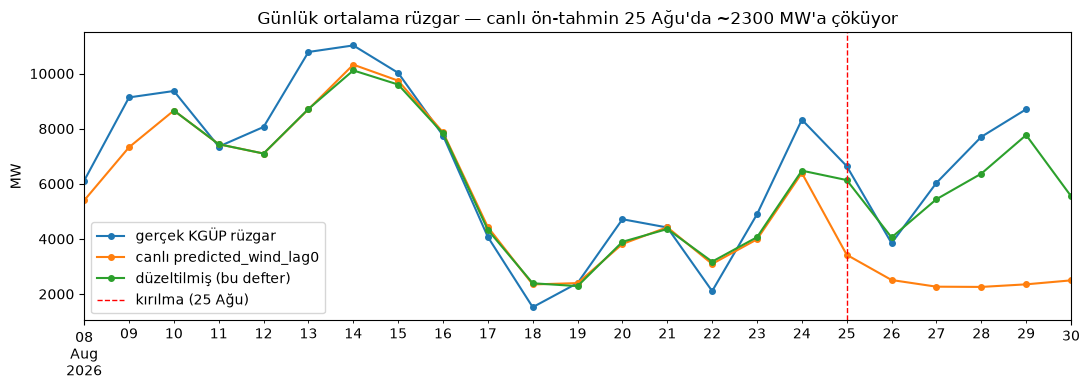

In [2]:
price   = q("SELECT ts, price_usd FROM raw_mcp_hourly WHERE ts >= '2026-08-05'", "price_usd")
wind_act = q("SELECT ts, wind_mw FROM raw_kgup_hourly WHERE ts >= '2026-08-05'", "wind_mw")
dbpf = q("""SELECT target_ts, predicted_wind_lag0 FROM gold.kgup_load_pre_forecasts
            WHERE target_ts >= '2026-08-05'""", "predicted_wind_lag0")
fixpf = pd.read_csv(H / "preforecast_recent_fixed.csv", index_col=0, parse_dates=True)
fixpf.index = toist(fixpf.index); fixpf = fixpf.sort_index()

g = pd.DataFrame({
    "gerçek KGÜP rüzgar":       wind_act.groupby(wind_act.index.normalize()).mean(),
    "canlı predicted_wind_lag0": dbpf.groupby(dbpf.index.normalize()).mean(),
    "düzeltilmiş (bu defter)":   fixpf["predicted_wind_lag0"].groupby(fixpf.index.normalize()).mean(),
}).loc["2026-08-08":"2026-08-30"].round(0)
print(g.to_string())

fig, ax = plt.subplots(figsize=(11, 4))
g.plot(ax=ax, marker="o", ms=4)
ax.axvline(pd.Timestamp("2026-08-25"), color="red", ls="--", lw=1, label="kırılma (25 Ağu)")
ax.set_ylabel("MW"); ax.set_title("Günlük ortalama rüzgar — canlı ön-tahmin 25 Ağu'da ~2300 MW'a çöküyor")
ax.legend(); plt.tight_layout(); plt.show()


In [3]:
# forecast API canlı logda hiç çağrılmamış — kanıt
import subprocess
log = ROOT.parent / "enerji_fiyat_tahmini" / "logs" / "daily_update.log"
if log.exists():
    fc = subprocess.run(["grep", "-c", "api.open-meteo.com/v1/forecast", str(log)], capture_output=True, text=True).stdout.strip()
    ar = subprocess.run(["grep", "-c", "archive-api.open-meteo.com", str(log)], capture_output=True, text=True).stdout.strip()
    print(f"canlı daily_update.log:  forecast API çağrısı = {fc}   |   archive API çağrısı = {ar}")


canlı daily_update.log:  forecast API çağrısı = 0   |   archive API çağrısı = 63


**Bulgu:** `predicted_wind_lag0` 25 Ağustos'a kadar gerçeği makul takip ediyor
(canlı ≈ düzeltilmiş), 25 Ağustos'tan sonra düz ~2300-2500 MW'a çöküyor — gerçek rüzgar
6000-8700 MW'a çıkarken. `daily_update.log`'da forecast API'ye **sıfır** çağrı var
(63 arşiv çağrısına karşılık). `train_and_predict_pre_forecasters` meteo kolonları NaN
iken koşup `kgup_wind_lag_1d..14d`'ye yaslanıyor → rampa-öncesi seviyede takılı kalıyor.


## 2. Lag azaltmak işe yaramıyor (`wind_lag_test_results.csv`)

In [4]:
wl = pd.read_csv(H / "wind_lag_test_results.csv", parse_dates=["gun"])
foc = wl[wl["gun"].between("2026-08-28", "2026-08-29")]
piv = foc.pivot_table(index="varyant", values=["MAE", "BIAS"], aggfunc="mean").round(0)
piv = piv.reindex(["base", "lag3", "lag1", "nolag", "lagonly", "meteoNaN", "ff05", "mono"])
piv.columns = ["BIAS (MW)", "MAE (MW)"]
print("Ağu 28-29 walk-forward, meteo = arşiv reanaliz (yani 'iyi meteo elde olsaydı'):")
print(piv.to_string())
print()
b_base = piv.loc["base", "BIAS (MW)"]; b_mnan = piv.loc["meteoNaN", "BIAS (MW)"]
print(f"· base (mevcut lag 1-14 + doğru meteo):  BIAS {b_base:+.0f} MW — rapordaki -5500 MW DEĞİL")
print(f"· meteoNaN (lag'ler baş başa):           BIAS {b_mnan:+.0f} MW — canlı arızayı yeniden üretiyor")
print(f"· lag3/lag1/nolag:                       BIAS DAHA KÖTÜ — lag azaltmak çözüm değil")


Ağu 28-29 walk-forward, meteo = arşiv reanaliz (yani 'iyi meteo elde olsaydı'):
          BIAS (MW)  MAE (MW)
varyant                      
base        -1136.0    1227.0
lag3        -1720.0    1726.0
lag1        -1687.0    1688.0
nolag       -1787.0    1787.0
lagonly     -1918.0    1997.0
meteoNaN    -5931.0    5931.0
ff05        -1156.0    1202.0
mono        -1340.0    1345.0

· base (mevcut lag 1-14 + doğru meteo):  BIAS -1136 MW — rapordaki -5500 MW DEĞİL
· meteoNaN (lag'ler baş başa):           BIAS -5931 MW — canlı arızayı yeniden üretiyor
· lag3/lag1/nolag:                       BIAS DAHA KÖTÜ — lag azaltmak çözüm değil


## 3. Düzeltme — düzgün meteo ile rüzgar ön-tahmin kalitesi

In [5]:
wind_all = q("SELECT ts, wind_mw FROM raw_kgup_hourly WHERE ts >= '2026-08-05'", "wind_mw")
load_act = q("SELECT ts, load_forecast_mw FROM raw_load_forecast_hourly WHERE ts >= '2026-08-05'", "load_forecast_mw")
solar_act = q("SELECT ts, solar_mw FROM raw_kgup_hourly WHERE ts >= '2026-08-05'", "solar_mw")
dbpf_all = pd.read_sql(text("""SELECT target_ts, predicted_load_lag0, predicted_solar_lag0, predicted_wind_lag0
                               FROM gold.kgup_load_pre_forecasts WHERE target_ts >= '2026-08-05'"""), eng)
dbpf_all["target_ts"] = pd.to_datetime(dbpf_all["target_ts"], utc=True)
dbpf_all = dbpf_all.set_index("target_ts"); dbpf_all.index = toist(dbpf_all.index); dbpf_all = dbpf_all.sort_index()

def mae_bias_wape(pred, act, idx):
    a = act.reindex(idx); p = pred.reindex(idx); k = a.notna() & p.notna()
    e = (p[k] - a[k])
    return e.abs().mean(), e.mean(), 100 * e.abs().sum() / a[k].abs().sum()

for lbl, a, b in [("Ağu 28-29 (arıza penceresi; 30 Ağu KGÜP yok)", "2026-08-28", "2026-08-29 23:00"),
                  ("Ağu 10-29 (tüm test)", "2026-08-10", "2026-08-29 23:00")]:
    idx = price.loc[a:b].index
    print(f"=== {lbl} ===")
    for name, act, pfcol in [("rüzgar", wind_all, "predicted_wind_lag0"),
                             ("güneş",  solar_act, "predicted_solar_lag0"),
                             ("yük",    load_act, "predicted_load_lag0")]:
        mb = mae_bias_wape(dbpf_all[pfcol], act, idx)
        mf = mae_bias_wape(fixpf[pfcol], act, idx)
        print(f"  {name:6s}  CANLI  MAE {mb[0]:6.0f}  BIAS {mb[1]:+7.0f}  WAPE {mb[2]:5.1f}%   "
              f"|  DÜZELTİLMİŞ  MAE {mf[0]:6.0f}  BIAS {mf[1]:+7.0f}  WAPE {mf[2]:5.1f}%")
    print()


=== Ağu 28-29 (arıza penceresi; 30 Ağu KGÜP yok) ===
  rüzgar  CANLI  MAE   5901  BIAS   -5901  WAPE  71.9%   |  DÜZELTİLMİŞ  MAE   1227  BIAS   -1136  WAPE  15.0%
  güneş   CANLI  MAE    978  BIAS    +976  WAPE  18.2%   |  DÜZELTİLMİŞ  MAE    976  BIAS    +976  WAPE  18.2%
  yük     CANLI  MAE   1430  BIAS   +1430  WAPE   3.1%   |  DÜZELTİLMİŞ  MAE   1497  BIAS   +1497  WAPE   3.3%

=== Ağu 10-29 (tüm test) ===
  rüzgar  CANLI  MAE   1686  BIAS   -1311  WAPE  26.0%   |  DÜZELTİLMİŞ  MAE    906  BIAS    -478  WAPE  14.0%
  güneş   CANLI  MAE    378  BIAS    +144  WAPE   6.0%   |  DÜZELTİLMİŞ  MAE    379  BIAS    +144  WAPE   6.0%
  yük     CANLI  MAE   1141  BIAS    -210  WAPE   2.4%   |  DÜZELTİLMİŞ  MAE   1084  BIAS    -287  WAPE   2.3%



## 4. Fiyat modeline etkisi — WF-LightGBM (canlı `lgb_lag0_v2` konfigü)

In [6]:
# wf_lgbm_recent_dbpf    : DB ön-tahmini (bozuk kuyruk) + T->T+1 proxy (Ağu 25+) — canlıyı üretir
# wf_lgbm_recent_fixedpf  : forecast-API rüzgarıyla düzeltilmiş ön-tahmin + aynı proxy
# ikisi de --proxy-from 2026-08-25: hedef-gün yük/KGÜP = dünün gerçekleşeni (sızıntı yok).
# TEK fark = rüzgar/güneş/yük ön-tahmini (predicted_*_lag0).
sdb = wf_daily("recent_dbpf")
sfx = wf_daily("recent_fixedpf")
live = q("SELECT target_ts, predicted_mcp_usd FROM gold.ptf_predictions_daily WHERE target_ts >= '2026-08-05'", "predicted_mcp_usd")

def metr(pred, idx):
    a = price.reindex(idx); p = pred.reindex(idx); k = a.notna() & p.notna()
    e = p[k] - a[k]
    naive = price.shift(24).reindex(idx); kn = k & naive.notna()
    rmae = e[kn[k]].abs().mean() / (naive[kn] - a[kn]).abs().mean()
    return dict(MAE=e.abs().mean(), BIAS=e.mean(),
                WAPE=100 * e.abs().sum() / a[k].abs().sum(), rMAE=rmae)

rows = []
for lbl, a, b in [("Ağu 28-30 (arıza penceresi)", "2026-08-28", "2026-08-30 23:00"),
                  ("Ağu 10-30", "2026-08-10", "2026-08-30 23:00")]:
    idx = price.loc[a:b].index
    for name, s in [("canlı ptf_predictions_daily", live), ("WF-LGBM (bozuk ön-tahmin)", sdb),
                    ("WF-LGBM (düzeltilmiş rüzgar)", sfx)]:
        m = metr(s, idx); m["pencere"] = lbl; m["model"] = name; rows.append(m)
tbl = pd.DataFrame(rows).set_index(["pencere", "model"])[["MAE", "BIAS", "WAPE", "rMAE"]].round(3)
print(tbl.to_string())


                                                             MAE    BIAS    WAPE   rMAE
pencere                     model                                                      
Ağu 28-30 (arıza penceresi) canlı ptf_predictions_daily   13.804  11.878  26.826  1.037
                            WF-LGBM (bozuk ön-tahmin)     14.629  13.182  28.430  1.099
                            WF-LGBM (düzeltilmiş rüzgar)  12.199   6.781  23.708  0.917
Ağu 10-30                   canlı ptf_predictions_daily    8.799   2.856  14.339  0.744
                            WF-LGBM (bozuk ön-tahmin)      8.583   2.087  13.986  0.726
                            WF-LGBM (düzeltilmiş rüzgar)   8.195   0.837  13.354  0.693


            gercek_usd  canli_MAE  canli_BIAS  wf_dbpf_MAE  wf_dbpf_BIAS  wf_fixedpf_MAE  wf_fixedpf_BIAS
gun                                                                                                      
2026-08-10        57.8       12.8         3.7         12.5           3.9            12.5              3.9
2026-08-11        66.3        7.5        -4.5          7.5          -4.8             7.5             -4.8
2026-08-12        63.9        5.0         2.9          5.2           2.8             5.0              2.5
2026-08-13        57.3        8.2         5.2          7.4           4.9             7.6              5.3
2026-08-14        57.4        8.5        -1.8          9.0          -2.6             9.1             -2.3
2026-08-15        50.4       10.1        10.1          3.5          -1.1             4.4             -1.5
2026-08-16        52.4        8.3        -6.1         10.7          -9.4            10.8             -9.6
2026-08-17        71.5        7.1         1.2 

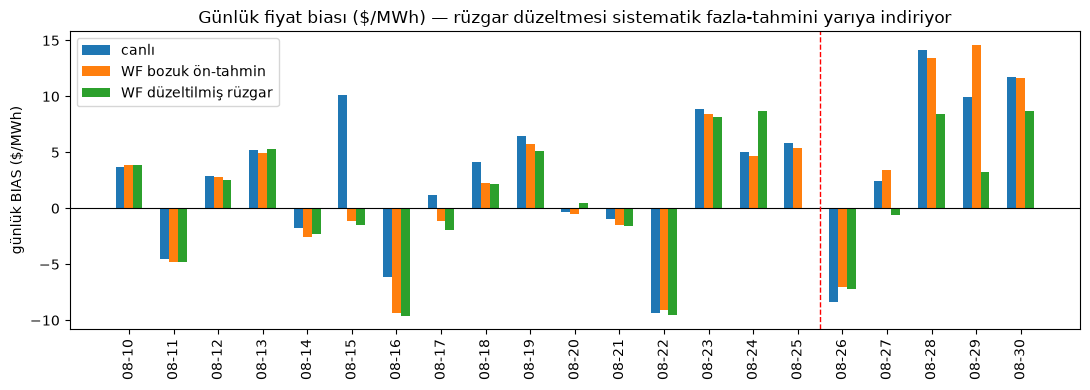

In [7]:
# gün gün
imp = pd.read_csv(H / "wind_fix_price_impact.csv", index_col=0)
print(imp.round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(np.arange(len(imp)) - 0.2, imp["canli_BIAS"], 0.2, label="canlı")
ax.bar(np.arange(len(imp)) + 0.0, imp["wf_dbpf_BIAS"], 0.2, label="WF bozuk ön-tahmin")
ax.bar(np.arange(len(imp)) + 0.2, imp["wf_fixedpf_BIAS"], 0.2, label="WF düzeltilmiş rüzgar")
ax.axhline(0, color="k", lw=0.8); ax.axvline(len(imp) - 5.5, color="red", ls="--", lw=1)
ax.set_xticks(range(len(imp))); ax.set_xticklabels([str(d)[5:] for d in imp.index], rotation=90)
ax.set_ylabel("günlük BIAS ($/MWh)"); ax.set_title("Günlük fiyat biası ($/MWh) — rüzgar düzeltmesi sistematik fazla-tahmini yarıya indiriyor")
ax.legend(); plt.tight_layout(); plt.show()


## Sonuç

**Arıza penceresi = 28-29-30 Ağustos.** Fiyat modeli üç gün de canlının **T→T+1 proxy'siyle**
koşuldu (`--proxy-from 2026-08-25`: hedef günün yük/KGÜP'ü = dünün gerçekleşeni). Ön-tahmincinin
rüzgar HIZI girdisi 29-30 Ağu için OpenMeteo **forecast API**'sinden (gerçek D-1 tahmini),
25-28 Ağu için arşiv reanaliz.

Rüzgar ön-tahmin kalitesi (Ağu 28-29; 30 Ağu gerçek rüzgar da henüz yayınlanmadı):

| | WAPE | BIAS |
|---|---|---|
| bozuk (canlı) | **71.9%** | −5901 MW |
| düzeltilmiş | **15.0%** | −1136 MW |

Fiyat, **Ağu 28-30** (WF-LightGBM = canlı `lgb_lag0_v2` konfigü + T→T+1 proxy, tek değişen = ön-tahmin):

| model | modelin dediği ort $ | MAE | BIAS | WAPE |
|---|---|---|---|---|
| canlı `ptf_predictions_daily` | $63.3 | $13.8 | +$11.9 | 26.8% |
| WF-LGBM, bozuk ön-tahmin (canlıyı üretir) | $64.6 | $14.6 | +$13.2 | 28.4% |
| WF-LGBM, **düzeltilmiş rüzgar** | **$58.2** | **$12.2** | **+$6.8** | **23.7%** |

_(gerçekleşen ort. fiyat Ağu 28-30 = $51.5)_

Gün gün — modelin dediği ort. fiyat (gerçek):

| gün | gerçek $ | canlı der | rüzgar düzeltilince der |
|---|---|---|---|
| 28 Ağu | 60.9 | $75 (+$14) | **$69 (+$8)** |
| 29 Ağu | 53.8 | $64 (+$10) | **$57 (+$3)** |
| 30 Ağu | 39.6 | $51 (+$12) | **$48 (+$9)** |

1. **Kök sebep girdi, mimari değil.** İleri rüzgar hızı 25 Ağustos'tan beri modele hiç
   ulaşmıyor (forecast API üretimde çağrılmıyor). `predicted_wind_lag0` düz ~2300 MW.
2. **Lag azaltmak yanlış yön** — BIAS'ı kötüleştiriyor. Doğru meteo ile mevcut lag 1-14
   modeli zaten iyi.
3. **Rüzgar düzeltmesi** Ağu 28-30 fiyat fazla-tahminini **+$11.9 → +$6.8**'e (29 Ağu tek
   başına +$10 → +$3) neredeyse yarıya indiriyor.
4. **Kalan fazla-tahmin** (30 Ağu +$9: fiyat $40'a çökmüş, model $48 diyor) rüzgar değil —
   model düşük-fiyat rejimini göremiyor: çöküş körlüğü / feature→fiyat eşleşmesi (Faz C.5.2).

### Canlıya taşınacak (bu repoda test edildi, `../enerji_fiyat_tahmini`'ye)

- `load_wind_features`: forecast API yarını gerçekten kapsamıyorsa `return hist` yerine
  **`raise`** — merge sonrası `gap`'in hedef 24 saatin 24'ünü kapsamasını şart koş.
- `assert_wind_available`: `sub.isna().all(axis=None)` çok gevşek (tek non-NaN geçiyor) →
  "herhangi bir hedef saatte 3 şehir birden NaN" veya kapsama < 24/24 ise raise.
- forecast API çağrısına 3× retry + backoff.
- Düz-eğri monitörü: son N gün `predicted_wind_lag0` aynı 24s şeklin ±X MW'ı içindeyse alarm.
- **Neden forecast API hiç çağrılmıyor** araştırılacak — deploy/kod-yolu sorunu (kod ağacında
  `fetch_openmeteo_wind_forecast` var, çalışan serviste görünmüyor).
